# Phase Analyzer

Analyzes the phase patterns, modelled as genetic instances, after optimization 

In [39]:
# Functions to import

import numpy as np 
import scipy as sp
import pygad
import yaml 
from yaml import Loader 

from scipy.fft import fft2, fftfreq, ifft2, fftshift, ifftshift
from scipy import ndimage
from optical_functions import LG, propFF, cart2pol, oamModes, output_chan, setKnotType, output_chan_symmetric, output_chan_triangle

import matplotlib.pyplot as plt 

from diffractsim import cm, mm, um 
import os

# from run_ga import compute_sorting_performance 

# Function which plots the phase and intensity of the field

'''
Jointly plots the intensity and phase patterns of the complex field.

Ex - complex 2D array -  field
'''

def TotInt(Ex):
    fig, ax =  plt.subplots(1,2,figsize=(10,10))
    ax[0].set_title('Intensity')
    intensity = ax[0].imshow(abs(Ex)**2,cmap="gist_gray")
    ax[0].axis('off')
    cbar=fig.colorbar(intensity, fraction=0.05, pad=0.04, ax=ax[0])
    
    
    ax[1].set_title('Phase')
    phase = ax[1].imshow(np.angle(Ex), cmap="hsv", interpolation='nearest')
    ax[1].axis('off')
    cbar=fig.colorbar(phase,fraction=0.05, pad=0.04, ax=ax[1])
    plt.show()

    
# Let's get the Fresnel propagator in there to see what happens when we slightly perturb the knot/introduce a phase shift 

'''
This propagates the beam using a Fresnal Diffraction Transfer Function approach. 

PARAMETERS
u1 - source plane
L - length of the numerical window (in units of w0)
la - lambda (m-1)
z - propagation distance (w0)
'''

def propTF(u1,L,la,z):
    M,nn=u1.shape
    dx=L/M
    fx=np.arange(-1/(2*dx),1/(2*dx),1/L)
    Fx, Fy = np.meshgrid(fx, fx)
    H=np.exp(-1j*np.pi*la*z*(Fx**2+Fy**2))
    
    H = fftshift(H)
    U2=H*fft2(fftshift(u1))
    u2=ifftshift(ifft2(U2))

    
    return u2 


In [40]:
from optical_functions import shannon_entropy


def compute_sorting_performance(phase_maps, list_of_OAMs):
    
    # Make the dimensionality of our sorting in terms of # of modes
    d = len(list_of_OAMs)
    
    # Now, this is the fitness parameter 
    sorting_performance = 0  

    # Actually, let's introduce the crosstalk matrix 
    crosstalk_matrix = np.zeros((num_of_output_chans, num_of_output_chans))
    
    # Let's introduce the secret key rate here, actually. 
    secret_key = 0

    for ii in range(d):

        # Define initial OAM field and correct output channel 

        field = list_of_OAMs[ii].oamBeam 
        
        # Do a proper normalization on the incident field 
        
        field = norm_field(field,h)
        
        # Compute the initial field intensity. This will be important for later
        
        int_knot = np.sum(np.abs(field)**2)
    
        # modulate the field by the first phase map 

        field_mod_1 = field*phase_maps[0]

        # let's simulate the propagation of the lens
        if (simulateLens):
            field_lens, _ = propFF(field_mod_1,maxx,la,fourier_lens)
        else: # Take the fourier transform 
            field_lens = fftshift(fft2(field_mod_1))
        
        # What happens next depends on whether we have one or two phase maps
        
        if(num_of_phase_maps==1):
            # Compute the field intensity 
            final_field = field_lens
        else:
            # modulate the field by the second phase map 
            field_mod_2 = field_lens*phase_maps[1]
            # simulate the lens field again. This is the final field. 
            if (simulateLens):
                field_lens_2, _ = propFF(field_mod_2, maxx, la, fourier_lens)
            else: 
                field_lens_2 = ifft2(ifftshift(field_mod_2))
            # compute the field intensity 
            # field_lens_2 = field_lens_2/np.max(np.abs(field_lens_2))
            
            final_field = field_lens_2
            #final_field_int = np.abs(field_lens_2)**2
        
        # We normalize the final field and compute the intensity 
        final_field = norm_field(final_field,h)
        final_field_int = np.abs(final_field)**2
        
        # Define full set of indices, as you would summing through a for loop
        full_index = np.arange(len(output_chans))   
        # Delete ii from the list of full_index, creating a new temporary array
        temp_index = np.delete(full_index, ii)
        # Sum up the "incorrect" channels 
        incorrect_chans = 0
        # New: to construct our crosstalk matrix, let's store the individual intensities
        incorrect_chan_ints = []
        
        for ind in temp_index:
            field_in_pupil = final_field_int*output_chans[ind]
            incorrect_chan_ints.append(np.sum(field_in_pupil))
            incorrect_chans += np.sum(field_in_pupil)
            
        #print(temp_index)
        #input()
            
        # Now, evaluate the sorting performance 
        correct_chans = np.sum(final_field_int*output_chans[ii])
        sorting_performance += correct_chans - incorrect_chans
        
        # Compute the detector effeciency 
        detect_eff = correct_chans/int_knot 
        crosstalk_matrix[ii,ii] = detect_eff 
        
        # Compute the crosstalk matrix. For more than two modes, we have to be a bit more meticulous with our approach. 
        
        for jj, ind in enumerate(temp_index):
            #(jj)
            #print(ind)
            crosstalk_eff = incorrect_chan_ints[jj]/int_knot
            crosstalk_matrix[ii, ind] = crosstalk_eff
            #input()
            
        #crosstalk_eff = incorrect_chans/int_knot
        #crosstalk_matrix[ii, (ii+1)%num_of_output_chans] = crosstalk_eff 
    
    # Compute the "QBER" using the off-diagonals of the crosstalk matrix 
    qber = crosstalk_matrix.sum() - np.trace(crosstalk_matrix)

        # Compute the secret key rate
    secret_key = np.log2(d) - 2*shannon_entropy(qber,d)
        
    return sorting_performance, crosstalk_matrix, secret_key

# Create field & modes of interest following yaml configuration

In [90]:
stream = open(f"configs/ga3.yaml", 'r')
cnfg = yaml.load(stream, Loader=Loader)

N = cnfg['dim']
num_of_output_chans = cnfg['num_output_chans']
output_chan_width = cnfg['output_chan_width'] * mm # in mm 
num_of_phase_maps = cnfg['num_maps']
instance_name = cnfg['ga_instance'] # directory name of best phases

print(num_of_output_chans) 
# Some parameters specifying the LG modes

LG_modes = cnfg['LG_modes']
w0 = cnfg['w0'] * mm # in mm!!

isKnot = cnfg['isKnot']
knotType = cnfg['knotType']
shapeParams = cnfg['shapeParams']
fourier_lens = cnfg['fourier_length']*cm # fourier length of both lens in cm
GFilterStrength=cnfg['gauss_filter_sigma']
channel_seperation = cnfg['channel_sep']

# Define the coordinate space 

la = 0.78*um
k=(2*np.pi)/la  # [m^-1] wavenumber    
N=128 # [Number of points per dimension]
maxx = 20*um*N  # Full length of the numerical window (m)

# Propagation Distance 
prop_dist = 0

# Let's apply a rotation
rot_phi = eval(cnfg['rot_angle'])
#rot_op = np.exp(1j*rot_phi*phi)

#rot_phi=np.pi/4

# Space definition 
dx = maxx/N
dy = maxx/N 

#okay let's just say h here is dx or dy for now WLOG (WITH ... loss of generality)

h = dx
X = dx*(np.arange(N) - N //2)
Y = dy*(np.arange(N) - N //2)

# Apply rotation operator on coords 

# X_rot = np.cos(rot_phi)*X - np.sin(rot_phi)*Y
# Y_rot = np.sin(rot_phi)*X + np.cos(rot_phi)*Y

xx,yy=np.meshgrid(X ,Y);

xx_rot = np.cos(rot_phi)*xx - np.sin(rot_phi)*yy
yy_rot = np.sin(rot_phi)*xx + np.cos(rot_phi)*yy

r, phi= cart2pol(xx_rot,yy_rot)

dr = r[1,0] - r[0,0]
dphi = phi[1,0] - phi[0,0]

''' 
Create the OAM beams that we need to sort 
'''
# Now create a list containing 'oamMode' objects 

list_of_OAMs = []
output_chans = output_chan_symmetric(X,Y,output_chan_width, maxx,num_of_output_chans, chan_sep=channel_seperation)
#output_chans = output_chan_triangle(X, Y, output_chan_width, maxx, chan_sep=channel_seperation) # This can only be used if we are explcitly sorting three channels

if(isKnot):
    for ii in range(len(knotType)):
        field = setKnotType(r, phi, w0, knotType[ii], shapeParams[ii])
        prop_field = field
        list_of_OAMs.append(oamModes(prop_field, output_chans[ii]))
else:
    for ii in range(len(LG_modes)):
        field = setKnotType(r, phi, w0, knotType[ii], shapeParams[ii])
        prop_field = propTF(field, maxx, la, prop_dist)
        list_of_OAMs.append(oamModes(prop_dist, output_chans[ii]))
        

2


In [91]:
print(num_of_output_chans)

2


In [92]:
rot_phi

0

(-0.5, 127.5, 127.5, -0.5)

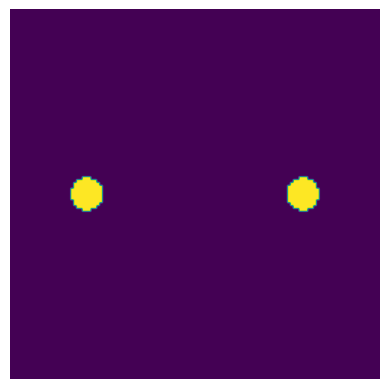

In [93]:
plt.imshow(output_chans[0] + output_chans[1])
plt.axis('off')

Create function which rotates the field

In [94]:
def create_rotated_knots(rot_phi):
    
    # Apply rotation operator on coords. Update: The rotation should be 
    # X_rot = np.cos(rot_phi)*X - np.sin(rot_phi)*Y
    # Y_rot = np.sin(rot_phi)*X + np.cos(rot_phi)*Y

    xx,yy=np.meshgrid(X ,Y);
    
    xx_rot = np.cos(rot_phi)*xx - np.sin(rot_phi)*yy
    yy_rot = np.sin(rot_phi)*xx + np.cos(rot_phi)*yy

    r, phi= cart2pol(xx_rot,yy_rot)

    ''' 
    Create the OAM beams that we need to sort 
    '''
    # Now create a list containing 'oamMode' objects 

    list_of_OAMs = []

    if(isKnot):
        for ii in range(len(knotType)):
            field = setKnotType(r, phi, w0, knotType[ii], shapeParams[ii])
            list_of_OAMs.append(oamModes(field, output_chans[ii]))
    else:
        for ii in range(len(LG_modes)):
            list_of_OAMs.append(oamModes(LG(r, phi, LG_modes[ii][0], LG_modes[ii][1], w0,h,0,k), output_chans[ii]))

    return list_of_OAMs


Create function which translates the field over x- and y- axis

In [95]:
def create_translated_knots(x_trans, y_trans):

    xx,yy=np.meshgrid(X ,Y);
    
    xx_trans = xx + x_trans
    yy_trans = yy + y_trans 

    r, phi= cart2pol(xx_trans,yy_trans)

    ''' 
    Create the OAM beams that we need to sort 
    '''
    # Now create a list containing 'oamMode' objects 

    list_of_OAMs = []

    if(isKnot):
        for ii in range(len(knotType)):
            field = setKnotType(r, phi, w0, knotType[ii], shapeParams[ii])
            list_of_OAMs.append(oamModes(field, output_chans[ii]))
    else:
        for ii in range(len(LG_modes)):
            list_of_OAMs.append(oamModes(LG(r, phi, LG_modes[ii][0], LG_modes[ii][1], w0,h,0,k), output_chans[ii]))

    return list_of_OAMs

# to test

list_of_OAMs = create_translated_knots(0.0*mm, 0.0*mm)

Plot output channels

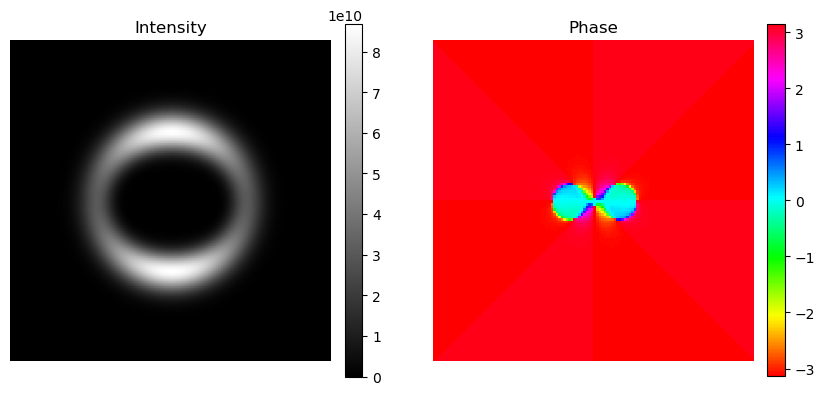

In [96]:
# Let's properly normalize the field, instead of scaling it from 0 to 1

def norm_field(field,h):
    norm_fac=np.sqrt(np.sum(np.abs(field*h)**2))
    print(norm_fac)
    return field/norm_fac 

field = list_of_OAMs[1].oamBeam 
#field_2 = propTF(field,maxx,la,0.5*cm)
TotInt(field)

# An Aside: Compute the Overlap Between Modes

In [97]:
mode1 = list_of_OAMs[0].oamBeam
mode2 = list_of_OAMs[1].oamBeam
mode3 = list_of_OAMs[2].oamBeam

### Compute the normof each field

def compute_norm(mode, rr, dr, dphi):
    integrand = rr*np.abs(mode)**2
    norm = np.sqrt(np.sum(integrand)*dr*dphi)
    return norm 

norm1 = compute_norm(mode1, r, dr, dphi)
norm2 = compute_norm(mode2, r, dr, dphi)
norm3 = compute_norm(mode3, r, dr, dphi)

# Apply normalization 

mode1 = mode1/norm1
mode2 = mode2/norm2
mode3 = mode3/norm3
    
integrand12 = np.conj(mode1)*mode2*r
integral12 = np.sum(integrand12)*dr*dphi
overlap_magnitude12 = np.abs(integral12)

integrand23 = np.conj(mode2)*mode3*r
integral23 = np.sum(integrand23)*dr*dphi
overlap_magnitude23 = np.abs(integral23)

integrand13 = np.conj(mode1)*mode3*r
integral13 = np.sum(integrand13)*dr*dphi
overlap_magnitude13 = np.abs(integral13)

print(f"Overlap Magnitude Between a Trefoil and a Cinquefoil: {overlap_magnitude12}")
print(f"Overlap Magnitude Between a Cinquefoil and a Figure-8: {overlap_magnitude23}")
print(f"Overlap Magnitude Between a Trefoil and a Figure-8: {overlap_magnitude13}")

IndexError: list index out of range

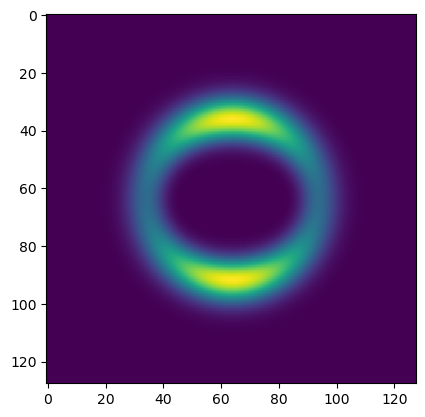

In [98]:
field_fft = fftshift(fft2(field))
field_ifft = ifft2(ifftshift(field_fft))

plt.imshow(np.abs(field_ifft)**2)

In the paper by Fickler, they consider phase holograms ... "that modulate the beam by atleast 40 x 40 pixels" 

In [99]:
count_x = 0
count_y = 0

# Here, we increment count_x because we are iterating in the horizontal direction 
for ii in range(N):
    for jj in range(N): 
        if(np.abs(field[ii,jj])**2 > 1e-10):
            count_x += 1

        
# Here, we increment count_y because we are iterating in the vertical direction 

for jj in range(N):
    for ii in range(N):
        if(np.abs(field[ii,jj])**2 > 1e-10):
            count_y += 1

Load genetic Instance

In [100]:
import pickle

index = 2

#instance_name = 'knots_smaller_oneMap'

with open(f"best_phases/{instance_name}.pkl", 'rb') as file:
     phase_out = pickle.load(file)
        
print(instance_name)

tref_figure8_G1000_normDouble


In [101]:
np.max(phase_out)

20.550731038559206

Compute phase screens and plot them 

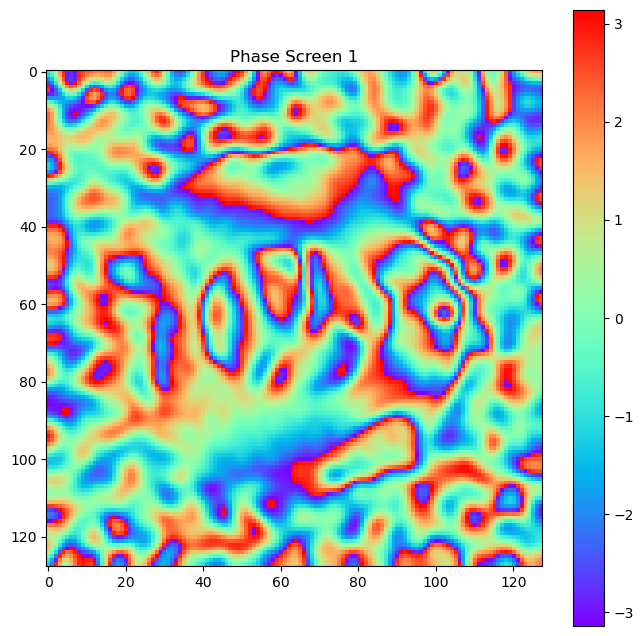

In [102]:
phase_maps = np.empty((num_of_phase_maps, N, N), dtype=np.complex_)

GFilterStrength = 0

# Compute phase screens and plot them 
for ii in range(num_of_phase_maps):
    # Apply extra gaussian filter on output data 
    phase_out[ii] =sp.ndimage.gaussian_filter(phase_out[ii], sigma=maxx*GFilterStrength)
    phase_maps[ii]= np.exp(1j*phase_out[ii])

#phaseScreenDos = np.exp(1j*phase_out[1,:,:])
phase_screen=0
fig, ax = plt.subplots(1,1, figsize=(8,8))
first = ax.imshow(np.angle(phase_maps[phase_screen]), cmap='rainbow')
ax.set_title(f"Phase Screen {phase_screen+1}")
c1 = fig.colorbar(first, ax=ax)

plt.show()

In [103]:
np.min(np.angle(phase_out))

0.0

Let's also consider an actual hologram here

In [104]:
# This function generates phase gratings in reminisce of OAM gratings 

def OAMWithGratings(l,rows,cols,xoffset,yoffset,a):
    
    crow, ccol = int(rows / 2)+xoffset, int(cols / 2)+yoffset
    mask = np.zeros((rows,cols)) +0j
    fx = 10.0
    fy = 0.0
    phi = np.zeros((rows,cols))+0j

    for i in range (rows):
        for j in range (cols):
            
            x = i - crow
            y = j - ccol
            alpha = l*np.arctan2(x,y) + 2*np.pi*10*y/128
            g = a[0] + a[1]*np.cos(2*alpha)  + a[2]*np.cos(3*alpha) + a[3]*np.cos(4*alpha)
                  #g = 1/4*(1 + np.cos(alpha) + np.cos(2*alpha) +  np.cos(3*alpha)+np.cos(4*alpha))
                  #g = np.mod(alpha,2*np.pi)
            mask[i,j] = g
        
    return(mask)

test_mask = OAMWithGratings(1,N,N,0,0,[1,1,1,1])

Compute the propagation for each mode

0.016533672705571805


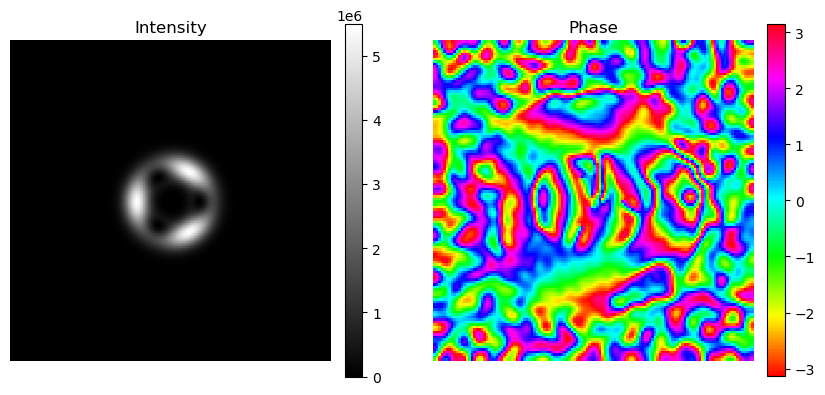

128.0


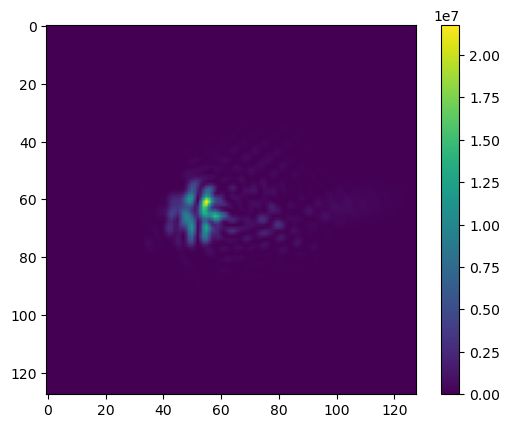

In [111]:
from scipy.fft import ifft2, ifftshift, fft2, fftshift
GFilterStrength = 0

# Let's pick an LG beam to analyze

mode_num = 0

field = list_of_OAMs[mode_num].oamBeam 
field = norm_field(field,h)

# Propagate the beam slightly using a Fresnel propagator 

field_2 = propTF(field,maxx, la, 0*cm)

# modulate the field by the first phase map 

field_mod_1 = field*phase_maps[0]

TotInt(field_mod_1)

# let's simulate the propagation of the lens

#field_lens, _ = propFF(field_mod_1,maxx,la,fourier_lens)
field_lens = fftshift(fft2(field_mod_1))
field_lens = norm_field(field_lens,h)

# compute the field intensity 

final_field_int = np.abs(field_lens)**2
final_final_field = sp.ndimage.gaussian_filter(final_field_int, sigma=maxx*GFilterStrength)

plt.imshow(final_final_field)
plt.colorbar()

# An Aside: How do the Overlaps Change after Applying The First Field? 

In [106]:
#field_lens = fftshift(fft2(field_mod_1))

mode1 = fftshift(fft2(list_of_OAMs[0].oamBeam*phase_maps[0]))
mode2 = fftshift(fft2(list_of_OAMs[1].oamBeam*phase_maps[0]))
mode3 = fftshift(fft2(list_of_OAMs[2].oamBeam*phase_maps[0]))

### Compute the normof each field

def compute_norm(mode, rr, dr, dphi):
    integrand = rr*np.abs(mode)**2
    norm = np.sqrt(np.sum(integrand)*dr*dphi)
    return norm 

norm1 = compute_norm(mode1, r, dr, dphi)
norm2 = compute_norm(mode2, r, dr, dphi)
norm3 = compute_norm(mode3, r, dr, dphi)

# Apply normalization 

mode1 = mode1/norm1
mode2 = mode2/norm2
mode3 = mode3/norm3
    
integrand12 = np.conj(mode1)*mode2*r
integral12 = np.sum(integrand12)*dr*dphi
overlap_magnitude12 = np.abs(integral12)

integrand23 = np.conj(mode2)*mode3*r
integral23 = np.sum(integrand23)*dr*dphi
overlap_magnitude23 = np.abs(integral23)

integrand13 = np.conj(mode1)*mode3*r
integral13 = np.sum(integrand13)*dr*dphi
overlap_magnitude13 = np.abs(integral13)

print(f"Overlap Magnitude Between a Trefoil and a Cinquefoil: {overlap_magnitude12}")
print(f"Overlap Magnitude Between a Cinquefoil and a Figure-8: {overlap_magnitude23}")
print(f"Overlap Magnitude Between a Trefoil and a Figure-8: {overlap_magnitude13}")

IndexError: list index out of range

The overlap doesn't change on immediate application of the phase, but the effect is more clear upon doing the optical fourier transform: the action is to reduce the overlap between the final fields. 

*******************************

Simulating the second phase map

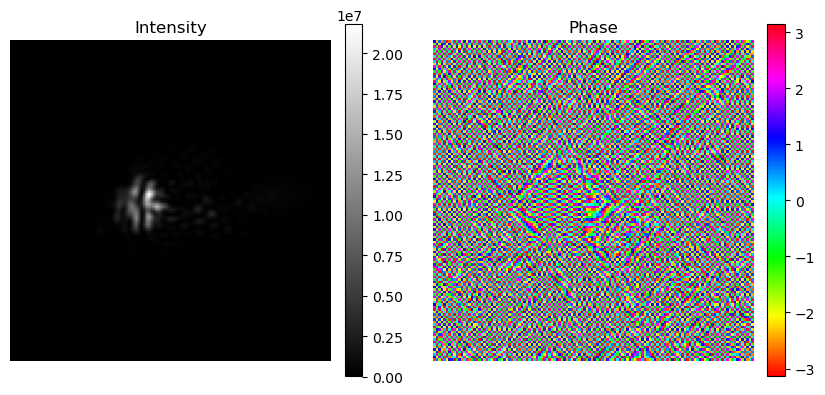

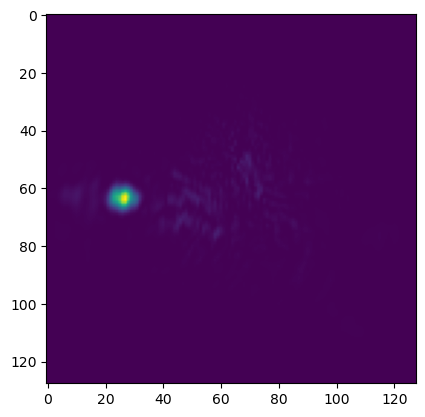

In [112]:
# modulate the field by the second phase map 

field_mod_2 = field_lens*phase_maps[1]

# simulate the lens field again. This is the final field. 

#field_lens_2, _ = propFF(field_mod_2, maxx, la, fourier_lens)
field_lens_2 = ifft2(ifftshift(field_mod_2))
TotInt(field_mod_2)
plt.imshow(abs(field_lens_2)**2)

# Compute the normalized sorting probability 

In [108]:
simulateLens = False
sorting_performance, crosstalk_matrix, _ = compute_sorting_performance(phase_maps, list_of_OAMs)

0.016533672705571805
1.0
224.72621268270808
0.9999999999999999


Compute the crosstalk matrix

[[0.46094782 0.00285215]
 [0.0008829  0.58996742]]
0.5254576207797773
0.001867529091755843


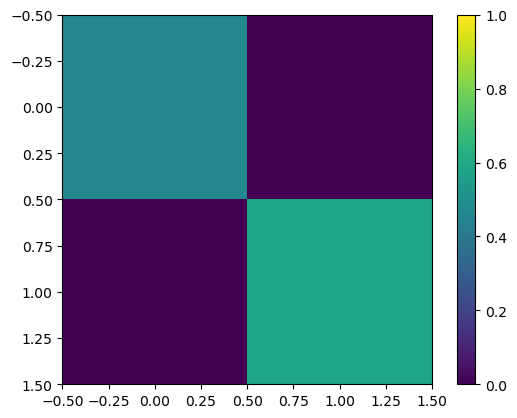

In [109]:
plt.figure()
plt.imshow(crosstalk_matrix, vmin=0.0, vmax=1.0)
plt.colorbar()

print(crosstalk_matrix)
print(np.mean([crosstalk_matrix[0,0], crosstalk_matrix[1,1]]))
print(np.mean([crosstalk_matrix[1,0], crosstalk_matrix[0,1]]))

# Effect of Rotation on Hologram 

In [ ]:
rotate_angles = np.linspace(0, 2*np.pi, num=50)
mean_effs = []
mean_crosses = []

for angle in rotate_angles: 
    # Generate the rotated fields
    list_of_rotated_OAMs = create_rotated_knots(angle)
    # Compute the crosstalk matrix 
    simulateLens = False
    sorting_performance, crosstalk_matrix = compute_sorting_performance(phase_maps, list_of_rotated_OAMs)
    
    # Report the mean on the detector efficency, crosstalk. 
    #mean_eff = np.mean([crosstalk_matrix[0,0], crosstalk_matrix[1,1]])
    #mean_cross = np.mean([crosstalk_matrix[1,0], crosstalk_matrix[0,1]])
    
    mean_eff = crosstalk_matrix[0,0]
    mean_cross = crosstalk_matrix[1,0]
    
    mean_effs.append(mean_eff)
    mean_crosses.append(mean_cross)

In [ ]:
plt.plot(rotate_angles, mean_effs, label='Mean Efficiency')
plt.plot(rotate_angles, mean_crosses, label='Mean Crosstalk')
plt.legend()
plt.show()

# Effect of Translation on Field Performance

In [76]:
x_translate = np.linspace(-0.1*mm, +0.1*mm, num=50)
y_translate = np.linspace(-0.1*mm, +0.1*mm, num=50)

effs = []
crosses = []

# How does the detector efficency and crosstalk change with the Trefoil? with the Cinquefoil? 

mode = 1 # 0 means trefoil, 1 means cinquefoil

for x_trans in x_translate:
    eff_row = []
    cross_row = []
    
    for y_trans in y_translate:
        
        # Generated the translated fields
        list_of_translated_OAMs = create_translated_knots(x_trans, y_trans)
        
        # Compute the crosstalk matrix
        simulateLens = False
        sorting_performance, crosstalk_matrix = compute_sorting_performance(phase_maps, list_of_translated_OAMs)
        
        # Extract the desired crosstalk/detector efficency 
        eff_row.append(crosstalk_matrix[mode,1])
        cross_row.append(crosstalk_matrix[mode,0])
    
    effs.append(eff_row)
    crosses.append(cross_row)

0.016533672705571805
128.0
61.855021159695745
127.99999999999999
0.016533672705571805
128.0
61.85502115969586
128.0
0.016533672705571805
128.0
61.855021159695944
127.99999999999999
0.016533672705571805
128.0
61.85502115969601
128.0
0.016533672705571805
128.0
61.85502115969605
128.0
0.016533672705571805
128.0
61.85502115969608
128.0
0.016533672705571805
128.0
61.85502115969611
128.0
0.016533672705571805
128.0
61.85502115969612
128.0
0.016533672705571805
128.0
61.85502115969614
127.99999999999999
0.016533672705571805
128.0
61.85502115969615
128.0
0.016533672705571805
128.0
61.85502115969616
127.99999999999999
0.016533672705571805
128.0
61.855021159696165
127.99999999999999
0.01653367270557181
127.99999999999999
61.855021159696165
128.0
0.016533672705571805
128.0
61.855021159696165
128.0
0.016533672705571805
128.0
61.85502115969617
127.99999999999999
0.016533672705571805
128.0
61.85502115969617
127.99999999999999
0.016533672705571805
128.0
61.85502115969617
128.0
0.016533672705571805
128.

0.016533672705571805
128.0
61.85502115969643
128.0
0.016533672705571805
128.0
61.855021159696435
127.99999999999999
0.016533672705571805
128.0
61.855021159696435
127.99999999999999
0.016533672705571805
128.0
61.855021159696435
127.99999999999999
0.016533672705571805
128.0
61.855021159696435
128.0
0.016533672705571805
128.00000000000003
61.855021159696435
127.99999999999999
0.016533672705571805
128.0
61.855021159696435
127.99999999999999
0.016533672705571805
128.0
61.855021159696435
127.99999999999999
0.016533672705571805
128.0
61.855021159696435
127.99999999999999
0.016533672705571805
128.0
61.855021159696435
127.99999999999999
0.016533672705571805
128.0
61.855021159696435
127.99999999999999
0.016533672705571805
128.0
61.855021159696435
127.99999999999999
0.016533672705571805
128.0
61.855021159696435
127.99999999999999
0.016533672705571805
128.0
61.855021159696435
128.0
0.016533672705571805
128.0
61.855021159696435
127.99999999999999
0.016533672705571805
128.0
61.85502115969643
128.0
0

0.016533672705571805
128.0
61.855021159696534
128.0
0.01653367270557181
127.99999999999999
61.855021159696534
128.0
0.016533672705571805
128.0
61.855021159696534
128.0
0.016533672705571805
128.00000000000003
61.855021159696534
128.0
0.016533672705571805
128.0
61.855021159696534
128.0
0.016533672705571805
128.0
61.855021159696534
128.0
0.016533672705571805
128.0
61.855021159696534
128.0
0.016533672705571805
128.0
61.855021159696534
128.0
0.016533672705571805
128.0
61.855021159696534
128.0
0.016533672705571805
128.0
61.85502115969654
127.99999999999999
0.016533672705571805
128.0
61.85502115969654
127.99999999999999
0.016533672705571805
128.0
61.85502115969654
127.99999999999999
0.016533672705571805
128.0
61.85502115969654
127.99999999999999
0.016533672705571805
128.0
61.85502115969654
127.99999999999997
0.016533672705571805
128.0
61.85502115969654
127.99999999999999
0.016533672705571805
128.0
61.855021159696534
128.0
0.016533672705571805
128.0
61.85502115969654
127.99999999999997
0.01653

0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.00000000000003
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969657
127.99999999999999
0.016533672705571805
128.0
61.85502115969658
128.0
0.016

0.016533672705571805
128.0
61.85502115969659
128.0
0.01653367270557181
127.99999999999999
61.85502115969659
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.00000000000003
61.85502115969659
128.0
0.016533672705571805
128.0
61.855021159696584
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.00000000000003
61.85502115969659
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.00000000000003
61.85502115969659
128.0
0.016533672705571805
128.00000000000003
61.85502115969659
128.0
0.016533672705571

...

0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.855021159696584
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.0
61.8550211596966
127.99999999999999
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.00000000000003
61.8550211596966
128.0
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.0
61.855021159696605
128.0
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.0
61.8550211596966
128.0
0.01653367270557

0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.0
61.8550211596966
127.99999999999999
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.0
61.8550211596966
127.99999999999999
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.0
61.8550211596966
127.99999999999999
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.0
61.8550211596966
128.0
0.016533672705571805
128.00000000000003
61.8550211596966
128.0
0.016533672705571805
128.0
61.8550211596966
1

0.016533672705571805
128.0
61.8550211596965
128.00000000000003
0.016533672705571805
128.0
61.855021159696534
128.0
0.016533672705571805
128.00000000000003
61.85502115969655
128.0
0.016533672705571805
128.0
61.85502115969656
128.0
0.016533672705571805
128.00000000000003
61.85502115969657
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.855021159696584
127.99999999999999
0.01653367270557181
127.99999999999999
61.855021159696584
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.00000000000003
61.85502115969659
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.0
61.85502115969659
128.0
0.016533672705571805
128.00000000000003
61.85502115969659
128.0
0.016533672705571805
128.0
61.85502115969659
128.00000000000003
0.016533672705571805
128.0
6

0.016533672705571805
128.0
61.85502115969649
128.0
0.016533672705571805
128.0
61.85502115969652
127.99999999999999
0.016533672705571805
128.0
61.855021159696534
128.0
0.016533672705571805
128.0
61.85502115969655
128.0
0.016533672705571805
128.0
61.855021159696555
128.0
0.016533672705571805
128.0
61.85502115969657
127.99999999999999
0.016533672705571805
128.0
61.85502115969657
128.0
0.016533672705571805
128.0
61.85502115969657
128.0
0.016533672705571805
128.0
61.85502115969657
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.0
61.85502115969658
128.00000000000003
0.016533672705571805
128.00000000000003
61.855021159696584
128.0
0.016533672705571805
128.0
61.85502115969658
128.0
0.016533672705571805
128.00000000000003
61.85502115969658
128.0
0.016533672705

128.00000000000003
0.016533672705571805
128.0
61.855021159696506
128.0
0.016533672705571805
128.00000000000003
61.85502115969651
128.00000000000003
0.016533672705571805
128.0
61.855021159696534
127.99999999999999
0.016533672705571805
128.0
61.855021159696534
128.0
0.016533672705571805
128.0
61.85502115969654
127.99999999999999
0.016533672705571805
128.0
61.85502115969655
128.0
0.016533672705571805
128.0
61.85502115969655
128.0
0.016533672705571805
128.0
61.85502115969655
128.0
0.01653367270557181
127.99999999999999
61.85502115969655
128.0
0.016533672705571805
128.0
61.855021159696555
127.99999999999999
0.016533672705571805
128.00000000000003
61.85502115969655
128.0
0.016533672705571805
128.0
61.85502115969655
128.0
0.016533672705571805
128.00000000000003
61.85502115969655
128.0
0.016533672705571805
128.0
61.855021159696555
127.99999999999999
0.016533672705571805
128.0
61.85502115969655
128.0
0.016533672705571805
128.0
61.855021159696555
127.99999999999999
0.016533672705571805
128.0
61.

Make a cool 3D plot because everyone likes 3D plots boy howdy

(0.0, 0.1)

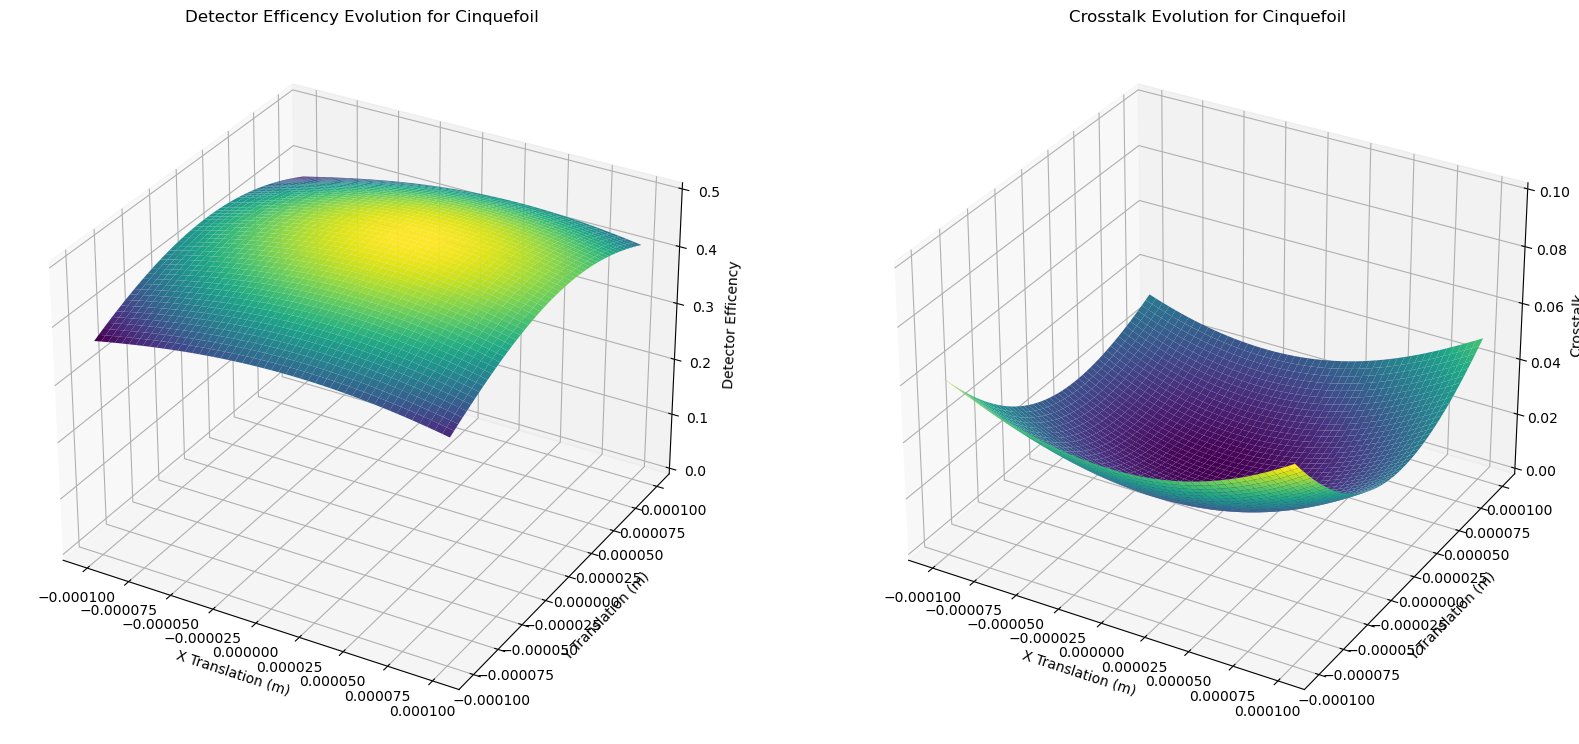

In [79]:
from mpl_toolkits.mplot3d import Axes3D

X_trans, Y_trans = np.meshgrid(x_translate, y_translate)

fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(121, projection='3d')
ax.plot_surface(X_trans, Y_trans, np.array(effs), cmap='viridis')
ax.set_xlabel('X Translation (m)')
ax.set_ylabel('Y Translation (m)')
ax.set_zlabel('Detector Efficency')
ax.set_title('Detector Efficency Evolution for Cinquefoil')
ax.set_zlim([0, 0.5])

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X_trans, Y_trans, np.array(crosses), cmap='viridis')
ax2.set_xlabel('X Translation (m)')
ax2.set_ylabel('Y Translation (m)')
ax2.set_zlabel('Crosstalk')
ax2.set_title('Crosstalk Evolution for Cinquefoil')
ax2.set_zlim([0, 0.1])